In [1]:
import sys
sys.path.insert(0, r"D:\OCRbyGPU\PIL_fix")
import os
import cv2  
import ultralytics
from ultralytics import YOLO
model = YOLO(r'c:\Users\HP\Desktop\ID_OCR\detect_id_card.pt')
import matplotlib.pyplot as plt
import numpy as np

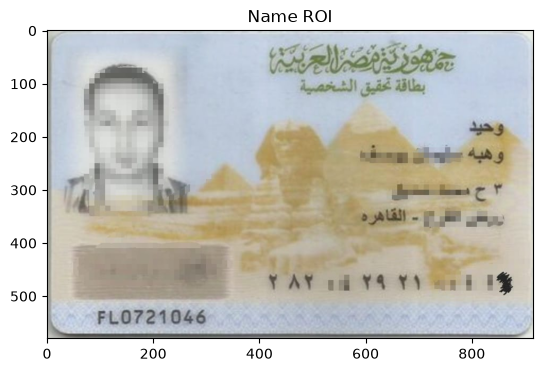

In [2]:
template = cv2.imread("test.jpeg")


plt.figure(figsize=(10, 4))

plt.imshow(
    cv2.cvtColor(
        template,
        cv2.COLOR_BGR2RGB
    )
)

plt.title("Name ROI")



plt.show()

ROI shape: (60, 150, 3)


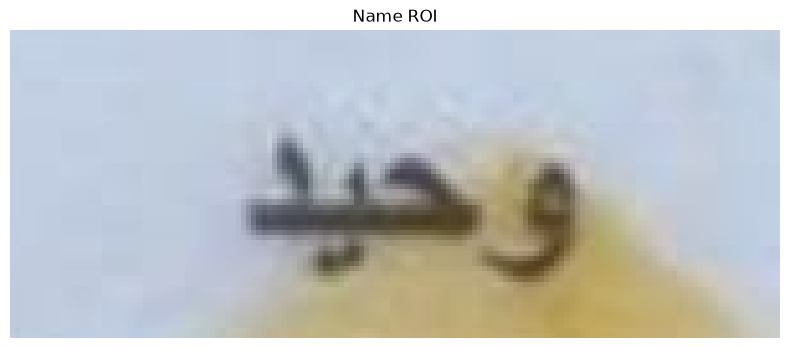

In [3]:
name_roi = template[150:210, 750:900]

print("ROI shape:", name_roi.shape)

plt.figure(figsize=(10, 4))

plt.imshow(
    cv2.cvtColor(
        name_roi,
        cv2.COLOR_BGR2RGB
    )
)

plt.title("Name ROI")

plt.axis("off")

plt.show()

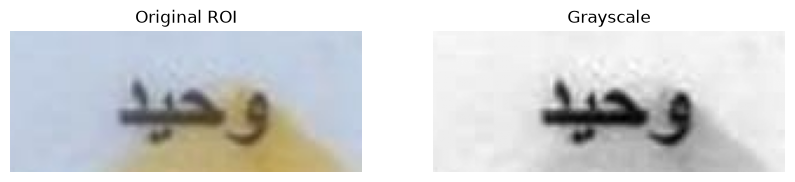

Original shape: (60, 150, 3)
Gray shape: (60, 150)


In [4]:
gray = cv2.cvtColor(
    name_roi,
    cv2.COLOR_BGR2GRAY
)
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(
    cv2.cvtColor(
        name_roi,
        cv2.COLOR_BGR2RGB
    )
)
plt.title("Original ROI")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(
    gray,
    cmap="gray"
)
plt.title("Grayscale")
plt.axis("off")

plt.show()

print("Original shape:", name_roi.shape)
print("Gray shape:", gray.shape)

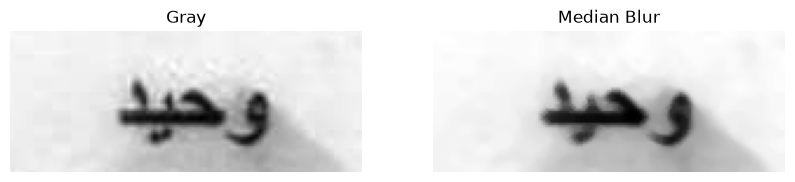

In [5]:
denoised = cv2.medianBlur(
    gray,
    5
)
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(
    gray,
    cmap="gray"
)
plt.title("Gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(
    denoised,
    cmap="gray"
)
plt.title("Median Blur")
plt.axis("off")

plt.show()

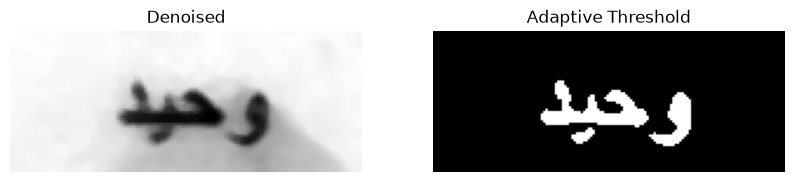

In [6]:
binary = cv2.adaptiveThreshold(
    denoised,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    21,
    7
)
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(
    denoised,
    cmap="gray"
)
plt.title("Denoised")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(
    binary,
    cmap="gray"
)
plt.title("Adaptive Threshold")
plt.axis("off")

plt.show()

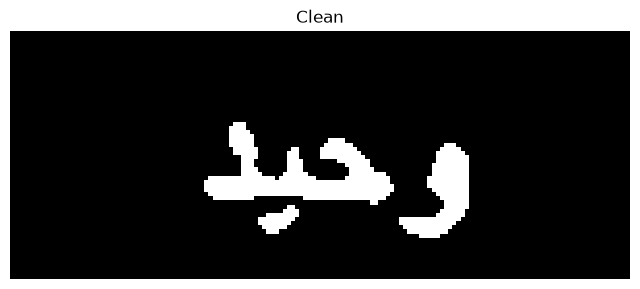

In [7]:
kernel = np.ones((2, 2), np.uint8)

clean = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)

plt.figure(figsize=(8, 4))
plt.imshow(clean, cmap="gray")
plt.title("Clean")
plt.axis("off")
plt.show()

In [8]:
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(clean, connectivity=8)
num_labels
for i in range(1, num_labels):
    x, y, w, h, area = stats[i]
    print("Component:", i, "x:", x, "y:", y, "w:", w, "h:", h, "area:", area)

Component: 1 x: 47 y: 22 w: 46 h: 20 area: 406
Component: 2 x: 94 y: 27 w: 17 h: 23 area: 193
Component: 3 x: 60 y: 42 w: 10 h: 7 area: 40


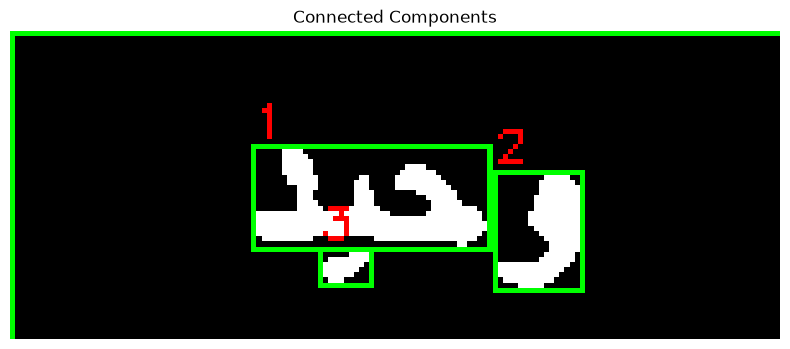

In [9]:
component_image = cv2.cvtColor(clean, cv2.COLOR_GRAY2BGR)

for i in range(0, num_labels):
    x, y, w, h, area = stats[i]
    cv2.rectangle(component_image, (x, y), (x + w, y + h), (0, 255, 0), 1)
    cv2.putText(component_image, str(i), (x, y - 2), cv2.FONT_HERSHEY_SIMPLEX, 0.3, (0, 0, 255), 1)

plt.figure(figsize=(12, 4))
plt.imshow(cv2.cvtColor(component_image, cv2.COLOR_BGR2RGB))
plt.title("Connected Components")
plt.axis("off")
plt.show()

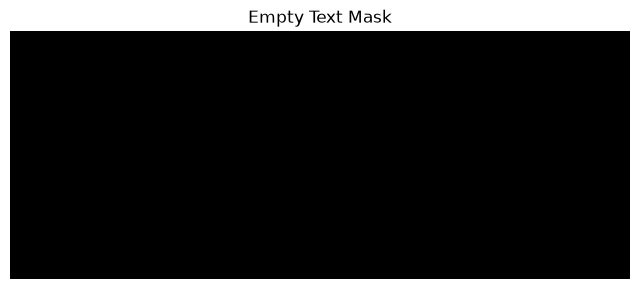

In [10]:
text_mask = np.zeros_like(clean)

plt.figure(figsize=(8, 4))
plt.imshow(text_mask, cmap="gray")
plt.title("Empty Text Mask")
plt.axis("off")
plt.show()
h_img, w_img = clean.shape

In [11]:
for i in range(1, num_labels):
    x, y, w, h, area = stats[i]
    print("Component:", i, "x:", x, "y:", y, "w:", w, "h:", h, "area:", area)

Component: 1 x: 47 y: 22 w: 46 h: 20 area: 406
Component: 2 x: 94 y: 27 w: 17 h: 23 area: 193
Component: 3 x: 60 y: 42 w: 10 h: 7 area: 40


In [12]:
for i in range(1, num_labels):
    x, y, w, h, area = stats[i]
    touches_border = (x == 0 or y == 0 or x + w >= w_img or y + h >= h_img)
    print("Component:", i, "Touches border:", touches_border)

Component: 1 Touches border: False
Component: 2 Touches border: False
Component: 3 Touches border: False


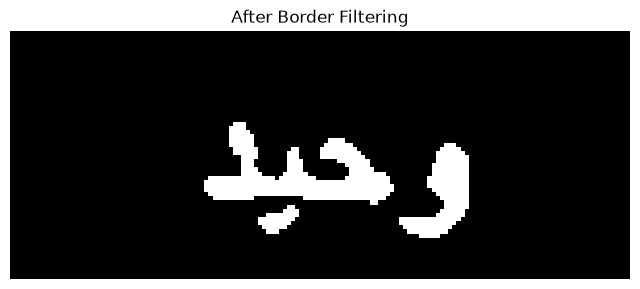

In [13]:
filtered_mask = np.zeros_like(clean)

for i in range(1, num_labels):
    x, y, w, h, area = stats[i]
    touches_border = (x == 0 or y == 0 or x + w >= w_img or y + h >= h_img)
    if touches_border:
        continue
    filtered_mask[labels == i] = 255

plt.figure(figsize=(8, 4))
plt.imshow(filtered_mask, cmap="gray")
plt.title("After Border Filtering")
plt.axis("off")
plt.show()

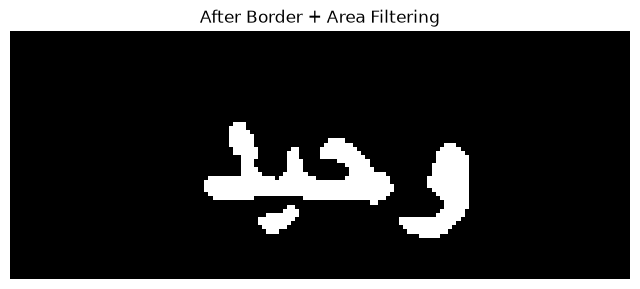

In [14]:
text_mask = np.zeros_like(clean)

for i in range(1, num_labels):
    x, y, w, h, area = stats[i]
    touches_border = (x == 0 or y == 0 or x + w >= w_img or y + h >= h_img)
    if touches_border:
        continue
    if area < 3:
        continue
    text_mask[labels == i] = 255

plt.figure(figsize=(8, 4))
plt.imshow(text_mask, cmap="gray")
plt.title("After Border + Area Filtering")
plt.axis("off")
plt.show()

In [15]:
row_counts = np.sum(text_mask > 0, axis=1)

print("Row counts:")
print(row_counts)

Row counts:
[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  3  4  5  6 10 16 22 26 26 23 22 23 29 46 55 56 55 52 37  8  8 10 15 24 22 18 13  5  0  0  0  0  0  0  0  0  0  0]


In [16]:
rows = np.where(row_counts > 2)[0]

print("Text rows:", rows)

Text rows: [22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49]


In [17]:
top = rows.min()
bottom = rows.max()

print("Top:", top)
print("Bottom:", bottom)

Top: 22
Bottom: 49


In [18]:
text_height = bottom - top + 1

print("Text Height:", text_height, "px")

Text Height: 28 px


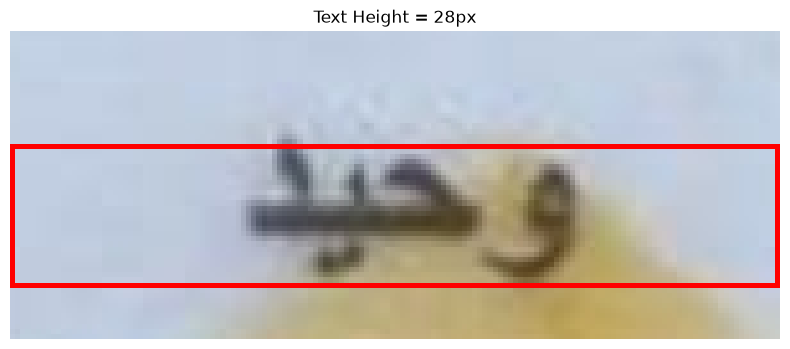

In [19]:
result = name_roi.copy()

cv2.rectangle(result, (0, top), (result.shape[1] - 1, bottom), (0, 0, 255), 1)

plt.figure(figsize=(12, 4))
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title(f"Text Height = {text_height}px")
plt.axis("off")
plt.show()